# Partie II – Régression : prédiction du nombre d’exacerbations

Groupe 1 : KENNICHE Redouane, ABAKAR Issa, AGHAJANI Dorsa, MUGISHA Abelard

## 1. Introduction

Dans cette deuxième partie du DC2, l'objectif est de développer un modèle capable de prédire le nombre d’exacerbations de l’asthme survenant dans l’année suivant la date d’index chez des patients asthmatiques.

Contrairement à la première partie du projet, où la variable cible était transformée en variable **binaire** (présence ou absence d’exacerbation), nous cherchons ici à prédire directement le nombre d’événements observés. La variable cible utilisée est :

`post_index_exacerbations365`

Cette variable représente le nombre total d’exacerbations d’asthme survenues dans les 365 jours suivant l’index. Elle prend donc des valeurs entières positives ou nulles :

$$
y \in \{0,1,2,3,\dots\}
$$

Il s’agit donc d’un problème de régression pour données de comptage (count data regression).

---

## Régression de Poisson

Dans un cadre statistique classique, les variables représentant des comptages d’événements sont souvent modélisées à l’aide d’une distribution de Poisson.

On suppose que le nombre d’exacerbations pour un patient \(i\) suit une loi de Poisson :

$$
Y_i \sim \mathcal{P}(\lambda_i)
$$

où :

- \(Y_i\) représente le nombre d’exacerbations pour le patient \(i\)
- \(\lambda_i > 0\) correspond à l’espérance du nombre d’événements pour ce patient

Dans un modèle de régression de Poisson, on suppose que le logarithme de cette espérance dépend linéairement des variables explicatives :

$$
\log(\lambda_i) = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \dots + \beta_p x_{ip}
$$

où :

- \(x_{ij}\) sont les variables explicatives (features)
- \(\beta_j\) sont les coefficients du modèle

On peut alors écrire :

$$
\lambda_i = \exp(\beta_0 + \beta_1 x_{i1} + \dots + \beta_p x_{ip})
$$

Cette formulation garantit que les valeurs prédites restent strictement positives, ce qui est cohérent avec la nature des données de comptage.

---

##  Métrique d’évaluation

Les performances du modèle seront évaluées à l’aide de la déviance de Poisson, qui mesure l’écart entre les valeurs observées et les valeurs prédites.

La formule utilisée est :

$$
D = 2 \sum_i \left( y_i \log\left(\frac{y_i}{\hat{y}_i}\right) - (y_i - \hat{y}_i) \right)
$$

où :

- \(y_i\) est la valeur observée
- \(\hat{y}_i\) est la valeur prédite par le modèle

Une déviance plus faible indique que les prédictions du modèle sont plus proches des observations réelles.


L’approche consiste à :

- préparer les données
- sélectionner les variables explicatives
- entraîner un modèle de régression
- évaluer ses performances à l’aide de métriques adaptées

## 2. Importations des bibliotheques


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from xgboost import XGBRegressor
from sklearn.metrics import mean_poisson_deviance
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import GridSearchCV


##  Description des données

Le dataset utilisé contient des informations cliniques et démographiques relatives à des patients atteints d’asthme.

Chaque observation correspond à un patient et comprend différentes variables explicatives telles que :

- caractéristiques démographiques
- informations médicales
- historique clinique

La variable cible est :

**post_index_exacerbations365**

Elle représente le **nombre d’exacerbations d’asthme observées dans les 365 jours suivant l’index clinique**.

L’objectif du modèle est donc de prédire cette quantité à partir des variables disponibles.

## 3. Chargement et inspection des données

Nous commençons par charger le jeu de données puis examiner sa structure afin de vérifier :

- le nombre d’observations
- le nombre de variables
- la présence éventuelle de valeurs manquantes

In [2]:
# Chargement du dataset
df = pd.read_csv("trainDataDC2.csv.gz", na_values=['NA', ''])

# Conversion en pandas pour utiliser scikit-learn

print("Dimensions du dataset :", df.shape)

df.head()


Dimensions du dataset : (14575, 21)


,patid,index_age,previous_asthma_drugs,total_pre_index_cannisters_365,post_index_exacerbations365,pneumonia,sinusitis,acute_bronchitis,acute_laryngitis,upper_respiratory_infection,...,rhinitis,adherence,total_pre_index_charge,pre_asthma_days,pre_asthma_charge,pre_asthma_pharma_charge,drug_s,female,log_charges,log_asthma_charge
0,1073754155,14.0,1.0,1.0,0,0.0,0.0,1.0,0.0,1.0,...,0.0,NaN,1224.767473,1.0,314.0,218.13,0.0,NaN,7.110506,5.385091
1,1073799394,NaN,1.0,2.0,2,0.0,1.0,1.0,0.0,0.0,...,1.0,NaN,20290.534269,0.0,NaN,44.98,0.0,0.0,9.917910,3.806218
2,1073854918,62.0,1.0,NaN,0,0.0,0.0,NaN,0.0,0.0,...,0.0,0.738420,2964.254175,NaN,480.0,99.26,0.0,0.0,7.994381,4.597743
3,1073898249,NaN,1.0,2.0,0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.084469,3223.708820,0.0,0.0,59.58,0.0,1.0,8.078288,NaN
4,1073913003,40.0,1.0,1.0,0,0.0,1.0,0.0,1.0,1.0,...,1.0,0.506812,1287.254368,2.0,689.0,NaN,0.0,0.0,7.160267,3.394173


## A. Analyse de la variable cible

La variable cible correspond au nombre d’exacerbations sur une période d’un an.

L’analyse descriptive de cette variable permet de comprendre :

- sa distribution
- sa dispersion
- la présence éventuelle de valeurs extrêmes

Ces informations sont importantes car elles influencent le choix du modèle de régression.

 Élément de liste
 Élément de liste



In [3]:
# Définition de la variable cible

target = "post_index_exacerbations365"

y = df[target]

print("Statistiques de la variable cible :")
print(y.describe())


Statistiques de la variable cible :
count    14575.000000
mean         0.175163
std          0.638298
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         13.000000
Name: post_index_exacerbations365, dtype: float64


In [4]:
df.describe()

,patid,index_age,previous_asthma_drugs,total_pre_index_cannisters_365,post_index_exacerbations365,pneumonia,sinusitis,acute_bronchitis,acute_laryngitis,upper_respiratory_infection,...,rhinitis,adherence,total_pre_index_charge,pre_asthma_days,pre_asthma_charge,pre_asthma_pharma_charge,drug_s,female,log_charges,log_asthma_charge
count,1.457500e+04,13085.000000,13144.0,13131.000000,14575.000000,13072.000000,13084.000000,13127.000000,13166.000000,13114.000000,...,13109.000000,12712.000000,13109.000000,13124.000000,13103.000000,13158.000000,13190.000000,13166.000000,13146.000000,13185.000000
mean,1.317034e+09,38.325793,1.0,0.794989,0.175163,0.050719,0.319703,0.262284,0.017089,0.223730,...,0.404989,0.253408,8473.137523,1.428223,553.973155,242.883670,0.162851,0.633298,7.982269,4.204495
std,1.546356e+08,15.210683,0.0,0.723036,0.638298,0.219432,0.466379,0.439893,0.129610,0.416759,...,0.490909,0.230140,21989.077382,2.467550,2024.886360,444.098457,0.369243,0.481923,1.645137,1.705917
min,1.073754e+09,12.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.005450,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.183442e+09,26.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.084469,1237.050948,0.000000,0.000000,21.410000,0.000000,0.000000,7.113415,3.063858
50%,1.282389e+09,41.000000,1.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.168937,3171.706218,1.000000,131.000000,46.160000,0.000000,1.000000,8.047814,3.849722
75%,1.493697e+09,51.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,...,1.000000,0.337875,8091.168039,2.000000,415.750000,227.737500,0.000000,1.000000,9.004598,5.438340
max,1.771899e+09,65.000000,1.0,2.000000,13.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,875872.580590,71.000000,79280.910000,5463.140000,1.000000,1.000000,13.682976,8.605779


## B. Analyse de la distribution de la variable cible

Afin de mieux comprendre le comportement de la variable cible, nous visualisons sa distribution à l’aide d’un histogramme.

Cette analyse permet d’identifier :
- la forme de la distribution
- la présence éventuelle d’asymétrie
- d’éventuelles valeurs extrêmes

Ces informations sont importantes pour choisir le modèle de régression approprié.

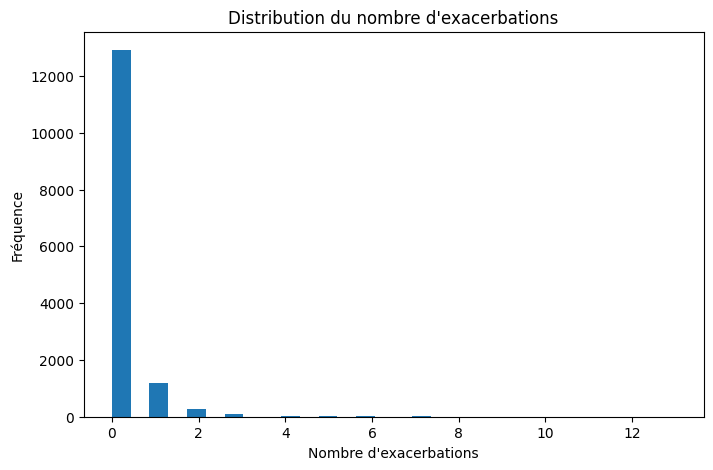

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(y, bins=30)
plt.title("Distribution du nombre d'exacerbations")
plt.xlabel("Nombre d'exacerbations")
plt.ylabel("Fréquence")
plt.show()

"La matrice de corrélation confirme que les antécédents d'exacerbations et la consommation de médicaments d'urgence (OCS, SABA) sont les variables les plus informatives pour notre modèle de régression. La forte corrélation entre les variables de coûts (charges) justifie l'utilisation de modèles robustes aux interactions comme XGBoost

# 4. Traitement des données

## A. Sélection des variables explicatives
Dans cette étape, nous définissons les variables explicatives utilisées pour entraîner notre modèle de régression.

Nous utilisons les mêmes variables que dans la première partie du projet afin de garantir la cohérence entre les deux approches.

Ces variables incluent :

- des variables démographiques (ex : âge du patient),
- des variables cliniques (diagnostics et comorbidités),
- des variables liées aux traitements,
- des variables économiques et d’adhérence au traitement.

Les variables sont ensuite séparées selon leur type afin d'appliquer les prétraitements appropriés.


In [6]:
# Définition des variables explicatives
# Suppression de la variable cible et de l'identifiant patient

X = df.drop(columns=["post_index_exacerbations365", "patid"])


###B.  Identification des types de variables

Les variables du dataset peuvent être de deux types :

- **variables numériques** : âge, mesures cliniques, etc.
- **variables catégorielles** : catégories médicales, diagnostics, traitements.

Cette distinction est importante car les techniques de prétraitement diffèrent selon le type de variable.

In [7]:
# Identification des types de variables

categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Nombre de variables catégorielles :", len(categorical_features))
print("Nombre de variables numériques :", len(numeric_features))


Nombre de variables catégorielles : 0
Nombre de variables numériques : 19


In [8]:
print("Variables catégorielles :")
print(categorical_features[:10])

print("\nVariables numériques :")
print(numeric_features[:10])


Variables catégorielles :
[]

Variables numériques :
['index_age', 'previous_asthma_drugs', 'total_pre_index_cannisters_365', 'pneumonia', 'sinusitis', 'acute_bronchitis', 'acute_laryngitis', 'upper_respiratory_infection', 'gerd', 'rhinitis']


### C. Analyse de correllation


Nous analysons la corrélation entre les variables numériques afin d’identifier d’éventuelles relations linéaires entre elles.

Cette étape permet également de détecter :

des variables fortement corrélées
des redondances potentielles dans les données

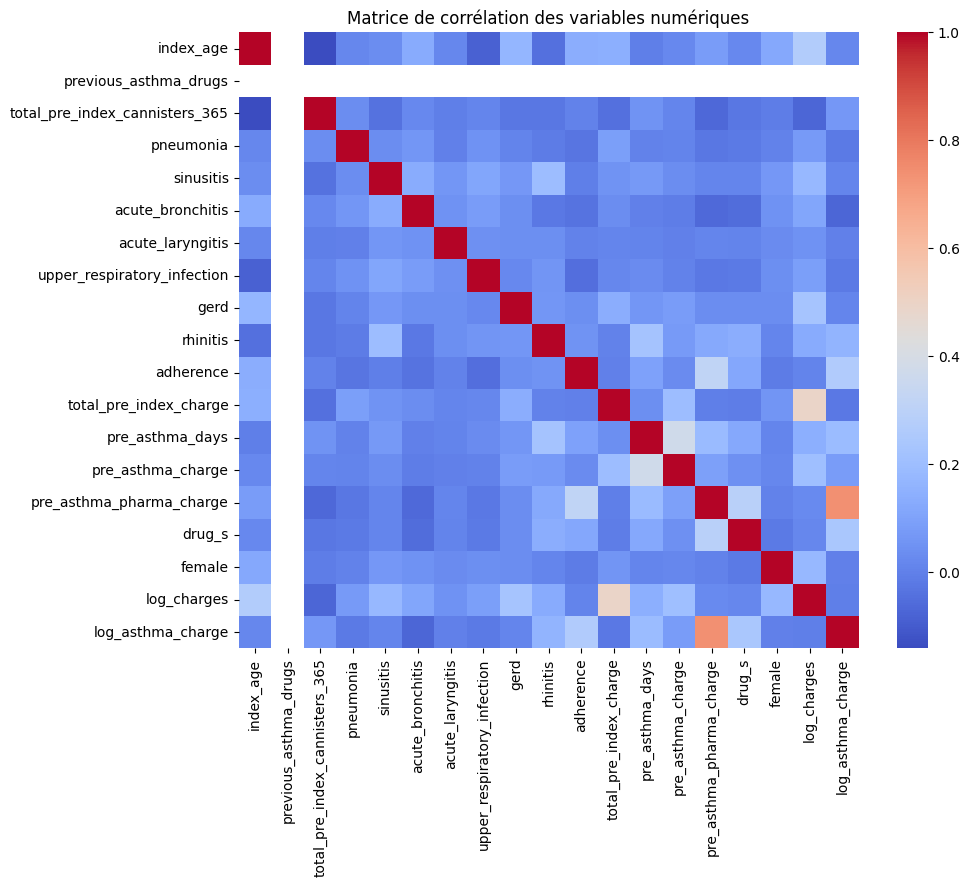

In [9]:
import seaborn as sns

corr = X.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Matrice de corrélation des variables numériques")
plt.show()

#5. Séparation des données

Les données sont divisées en deux ensembles :

- **jeu d’entraînement** : utilisé pour apprendre les paramètres du modèle
- **jeu de test** : utilisé pour évaluer les performances du modèle sur des données jamais vues

Cette étape permet d’éviter le surapprentissage et d’obtenir une estimation réaliste des performances du modèle.

In [10]:
# Séparation train/test

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Taille de X_train :", X_train.shape)
print("Taille de X_test  :", X_test.shape)
print("Taille de y_train :", y_train.shape)
print("Taille de y_test  :", y_test.shape)


Taille de X_train : (11660, 19)
Taille de X_test  : (2915, 19)
Taille de y_train : (11660,)
Taille de y_test  : (2915,)


## 6. Prétraitement des données

Les données doivent être transformées avant l'entraînement du modèle.

Deux transformations principales sont appliquées :

### Variables numériques
Les variables numériques sont standardisées à l’aide d’un **StandardScaler** afin de centrer les données et réduire les différences d’échelle.

### Variables catégorielles
Les variables catégorielles sont transformées via un **One-Hot Encoding**, qui convertit chaque catégorie en variables binaires.

Ces transformations sont regroupées dans un **ColumnTransformer**, ce qui permet de construire un pipeline de traitement cohérent.

In [11]:
# Prétraitement des variables numériques et catégorielles

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


#7. Optimisation des Hyperparamètres et Validation Croisée

In [24]:
# 1. On recrée le pipeline de base
# L'utilisation de Pipeline permet d'enchaîner le prétraitement (imputation, scaling) et le modèle dans un seul objet.
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(objective="count:poisson", random_state=42))
])

# 2. Grille de paramètres à tester
param_grid = {
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__n_estimators': [100, 200, 300],
    'model__max_delta_step': [1, 5],
    'model__min_child_weight': [1, 5]
}

# 3. Configuration de la recherche
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    scoring='neg_mean_poisson_deviance',
    cv=5,
    n_jobs=-1 #
)

# 4. On lance l'entraînement (cela peut prendre quelques minutes)
grid_search.fit(X_train, y_train)

# 5. Affichage des résultats
print("Meilleurs paramètres trouvés :", grid_search.best_params_)

# 6. Évaluation sur le jeu de test et Application du SEUIL
best_pipeline = grid_search.best_estimator_

# A. Prédictions brutes (valeurs décimales issues du modèle Poisson)
y_pred_brut = best_pipeline.predict(X_test)

# B. Définition et application du seuil
seuil = 0.25 # <-- C'est ici que vous pouvez jouer avec le curseur (ex: 0.15, 0.20, 0.30...)

# Si la prédiction brute est >= seuil, on force à au moins 1 (ou l'entier supérieur si la prédiction est > 1.5)
# Sinon, on met à 0
y_pred_seuil = np.where(y_pred_brut >= seuil, np.maximum(1, np.round(y_pred_brut)), 0)

# Affichage pour vérifier la répartition après le seuil
print(f"\n--- Répartition des prédictions (avec seuil à {seuil}) ---")
print(pd.Series(y_pred_seuil).value_counts())



Meilleurs paramètres trouvés : {'model__learning_rate': 0.01, 'model__max_delta_step': 1, 'model__max_depth': 4, 'model__min_child_weight': 1, 'model__n_estimators': 300}

--- Répartition des prédictions (avec seuil à 0.25) ---
0.0    2852
1.0      63
Name: count, dtype: int64


In [25]:
# Le jeu de données est divisé en 5 parties. Le modèle s'entraîne sur 4 et teste sur la 5ème.
#Cette opération est répétée 5 fois.
#Cela garantit que la performance du modèle est robuste et ne dépend pas d'un "coup de chance" lors de la division des données.
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(
    xgb_pipeline,
    X_train,
    y_train,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

rmse_scores = -scores

print("RMSE par fold :", rmse_scores)
print("RMSE moyen :", rmse_scores.mean())

RMSE par fold : [0.59036392 0.67010581 0.5822776  0.56470978 0.6980623 ]
RMSE moyen : 0.6211038827896118


In [14]:
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['index_age',
                                                   'previous_asthma_drugs',
                                                   'total_pre_index_cannisters_365',
                                                   'pneumonia', 'sinusitis',
                                                   'acute_bronchitis',
                                                   'acute_laryngitis',
                                                   'upper_respiratory_infection',
                                                   'gerd', 'rhinitis',
                                                   'adheren...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=None,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=None, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=None, n_jobs=None,
                              num_parallel_tree=None, ...))])

# 8. Évaluation du model sur le jeu de test

In [26]:
# Nous utilisons la déviance de Poisson plutôt que l'erreur quadratique classique (MSE),
#car la déviance est la mesure mathématique naturelle pour évaluer la qualité d'ajustement d'une loi de Poisson.
best_pipeline = grid_search.best_estimator_
y_pred_test_opti = best_pipeline.predict(X_test)


print("\nÉVALUATION DU MODEL")
print(f"Déviance de Poisson : {mean_poisson_deviance(y_test, y_pred_test_opti):.4f}")
print(f"RMSE                 : {np.sqrt(mean_squared_error(y_test, y_pred_test_opti)):.4f}")
print(f"MAE                  : {mean_absolute_error(y_test, y_pred_test_opti):.4f}")


ÉVALUATION DU MODEL
Déviance de Poisson : 0.9323
RMSE                 : 0.7256
MAE                  : 0.3270


# 9. Prédictions finales et Création du fichier de soumission

In [28]:
# 1. Prédictions brutes sur l'intégralité du dataset (X)
y_pred_all_brut = best_pipeline.predict(X)

# 2. Application du seuil validé (0.25)
y_pred_all_seuil = np.where(y_pred_all_brut >= 0.25, np.maximum(1, np.round(y_pred_all_brut)), 0)

# 3. Vérification de la nouvelle distribution globale
print("Nouvelle distribution finale pour le CSV :")
print(pd.Series(y_pred_all_seuil).value_counts())

# 4. Création et sauvegarde du fichier de soumission
submission = pd.DataFrame({
    "patid": df["patid"],
    "prediction": y_pred_all_seuil.astype(int) # Format entier requis par le cahier des charges
})

submission.to_csv("predictions_regression_final.csv", index=False)
print("Fichier CSV généré avec succès !")


Nouvelle distribution finale pour le CSV :
0.0    14248
1.0      327
Name: count, dtype: int64
Fichier CSV généré avec succès !


## 9. Conclusion

Dans cette deuxième partie du projet, nous avons développé un modèle de régression visant à prédire le nombre d’exacerbations de l’asthme dans l’année suivant la date d’index.

Afin d’obtenir de meilleures performances, nous avons utilisé un modèle XGBoost avec une fonction objectif de type Poisson (`count:poisson`). Cette approche a permis de mieux capturer les relations non linéaires entre les variables explicatives et le nombre d’exacerbations.

Les résultats obtenus montrent que le modèle final ne prédit pas uniquement des zéros, mais génère également un petit nombre de prédictions positives, ce qui est plus cohérent avec la structure réelle des données. Cela suggère que le modèle est capable de détecter certains profils de patients présentant un risque plus élevé d’exacerbations.

Enfin, nous avons généré un fichier de soumission au format demandé, contenant pour chaque patient son identifiant (`patid`) ainsi que le nombre d’exacerbations prédit.